# Laboratorio 1. Series de Tiempo

## Modelado de las series de fronteras

Fernando Rueda - 23748

Fernando Hernández - 23645

Este cuaderno cubre el modelado completo (incisos 4f al 4k) para las tres series de fronteras:
La Aurora, Valle Nuevo y San Cristóbal. Parte del diagnóstico del análisis preliminar
(`analisis-series.ipynb`): las tres series se modelan en logaritmo, con d = 1 confirmado por la
prueba de Dickey-Fuller aumentada y componente estacional de período 12.

Secciones 1 a 5: rejilla de modelos SARIMA por serie, comparación por AIC y BIC, análisis de
residuos y contraste con auto_arima de pmdarima. Secciones 6 a 8: modelos alternativos
(Prophet, Holt-Winters, suavizamiento exponencial y seasonal naive), pronóstico sobre el
conjunto de prueba, comparación por MAE y RMSE y selección del mejor modelo por serie. Sección
9: análisis comparativo entre las tres fronteras (inciso 5a).

Todo el ajuste se hace sobre el conjunto de entrenamiento (enero 2009 a marzo 2021); el
conjunto de prueba se usa exclusivamente para evaluar pronósticos.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmdarima as pm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")  # los SARIMA de la rejilla avisan sobre convergencia sin afectar el resultado

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURAS = RAIZ / "reports" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
AZUL, NARANJA, AQUA, AMARILLO, MAGENTA = PALETA
GRIS = "#8a8a85"

plt.rcParams.update({
    "figure.figsize": (11, 4.2),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e4e4e0",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "font.size": 10,
    "legend.frameon": False,
})

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(FIGURAS / f"{nombre}.png", bbox_inches="tight", facecolor="white")

pd.set_option("display.width", 160)

/Users/ferahmz/Documents/uvg/octavo/Data Science/Laboratorio-1-Series-de-Tiempo/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
train = pd.read_csv(RAIZ / "data" / "processed" / "series_train.csv", parse_dates=["fecha"]).set_index("fecha").asfreq("MS")

FRONTERAS = ["frontera: La Aurora", "frontera: Valle Nuevo", "frontera: San Cristóbal"]
logs = {nombre: np.log(train[nombre]) for nombre in FRONTERAS}
print(f"Entrenamiento: {train.index.min():%Y-%m} a {train.index.max():%Y-%m}, {len(train)} meses")

Entrenamiento: 2009-01 a 2021-03, 147 meses


## 1. Metodología

**Candidatos.** El análisis preliminar dejó como punto de partida el SARIMA(0,1,1)(0,1,1)₁₂
sobre el log, con la parte regular sugerida por el rezago 1 negativo de los correlogramas y la
estacional por el rezago 12. Alrededor de ese candidato ajustamos una rejilla de nueve modelos:
variantes AR contra MA en la parte regular (p, q en {0, 1, 2}), variantes AR contra MA en la
estacional (P, Q en {0, 1}), y dos variantes con D = 0 para las fronteras donde la diferencia
estacional quedó como opcional (La Aurora y Valle Nuevo).

**Comparación.** AIC y BIC comparan el ajuste penalizando parámetros. Solo son comparables
entre modelos con la misma diferenciación, porque cambiar d o D cambia la serie sobre la que se
calcula la verosimilitud; los modelos con D = 0 se evalúan aparte por sus residuos. El segundo
criterio es la prueba de Ljung-Box sobre los residuos: un buen modelo deja residuos sin
autocorrelación (p > 0.05 significa residuos compatibles con ruido blanco).

**Advertencia sobre el tramo pandémico.** Los últimos doce meses del entrenamiento son el
colapso de 2020. Ningún SARIMA con estacionalidad fija puede seguir una caída del 99%, así que
los residuos de 2020 van a ser enormes en todas las especificaciones. Eso no distingue entre
candidatos (castiga a todos por igual) pero sí contamina las pruebas de normalidad y, como se
verá en La Aurora, puede dejar autocorrelación residual que ningún orden extra elimina.

In [3]:
CANDIDATOS = [
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 0), (0, 1, 1, 12)),
    ((1, 1, 1), (0, 1, 1, 12)),
    ((0, 1, 2), (0, 1, 1, 12)),
    ((0, 1, 1), (1, 1, 0, 12)),
    ((0, 1, 1), (0, 1, 0, 12)),
    ((0, 1, 2), (0, 1, 0, 12)),
    ((0, 1, 1), (1, 0, 1, 12)),   # D = 0
    ((1, 1, 1), (1, 0, 1, 12)),   # D = 0
]


def etiqueta(orden, sorden):
    return f"SARIMA{orden}x{sorden[:3]}12"


def ajustar_rejilla(y):
    """Ajusta los candidatos y devuelve la tabla de comparación y los resultados."""
    filas, ajustes = [], {}
    for orden, sorden in CANDIDATOS:
        r = SARIMAX(y, order=orden, seasonal_order=sorden).fit(disp=False)
        resid = r.resid[r.loglikelihood_burn:]
        filas.append({
            "modelo": etiqueta(orden, sorden),
            "D": sorden[1],
            "AIC": round(r.aic, 1),
            "BIC": round(r.bic, 1),
            "Ljung-Box p (12)": round(acorr_ljungbox(resid, lags=[12]).iloc[0, 1], 3),
            "Ljung-Box p (24)": round(acorr_ljungbox(resid, lags=[24]).iloc[0, 1], 3),
        })
        ajustes[etiqueta(orden, sorden)] = r
    tabla = pd.DataFrame(filas).set_index("modelo").sort_values(["D", "AIC"], ascending=[False, True])
    return tabla, ajustes


def diagnostico_residuos(resultado, titulo, nombre_figura):
    fig = resultado.plot_diagnostics(figsize=(11, 7), lags=24)
    fig.suptitle(titulo, y=1.0)
    guardar(nombre_figura)
    plt.show()

## 2. La Aurora

### 2.1 Rejilla de modelos SARIMA

In [4]:
tabla_aurora, ajustes_aurora = ajustar_rejilla(logs["frontera: La Aurora"])
tabla_aurora

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,194.8,203.5,0.013,0.373
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,195.5,204.2,0.014,0.381
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,195.6,204.3,0.014,0.385
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,197.2,208.8,0.014,0.384
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,197.2,208.7,0.013,0.368
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,199.1,204.9,0.012,0.339
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,200.8,209.5,0.011,0.330
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,202.6,214.5,0.028,0.490
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,204.0,218.9,0.030,0.503


Entre los modelos con D = 1, que son comparables entre sí, el mejor AIC es el
**SARIMA(0,1,1)(1,1,0)₁₂** con 194.8, seguido a menos de un punto por el airline
SARIMA(0,1,1)(0,1,1)₁₂ (195.5) y el SARIMA(1,1,0)(0,1,1)₁₂ (195.6). Diferencias de AIC menores
a 2 no son concluyentes, así que los tres son estadísticamente equivalentes en ajuste; el BIC
ordena igual. Agregar órdenes (p o q en 2, o ambos términos estacionales) solo empeora el
criterio: la penalización por parámetros no se paga.

Los dos modelos con D = 0, la ruta alternativa que dejó abierta el análisis preliminar, no la
justifican: sus residuos no son mejores (Ljung-Box en 12 de 0.028 contra 0.013) y trasladan la
estacionalidad a un AR estacional cerca de la no invertibilidad. Nos quedamos con D = 1.

La columna de Ljung-Box en el rezago 12 merece atención: **todos** los candidatos con D = 1
quedan entre 0.011 y 0.014, debajo de 0.05. Ningún orden adicional lo arregla (probamos también
(0,1,1)(1,1,1)₁₂ y (1,1,1)(1,1,1)₁₂ fuera de la rejilla, con LB12 de 0.014). La causa se ve en
el diagnóstico de abajo.

### 2.2 Residuos del modelo elegido

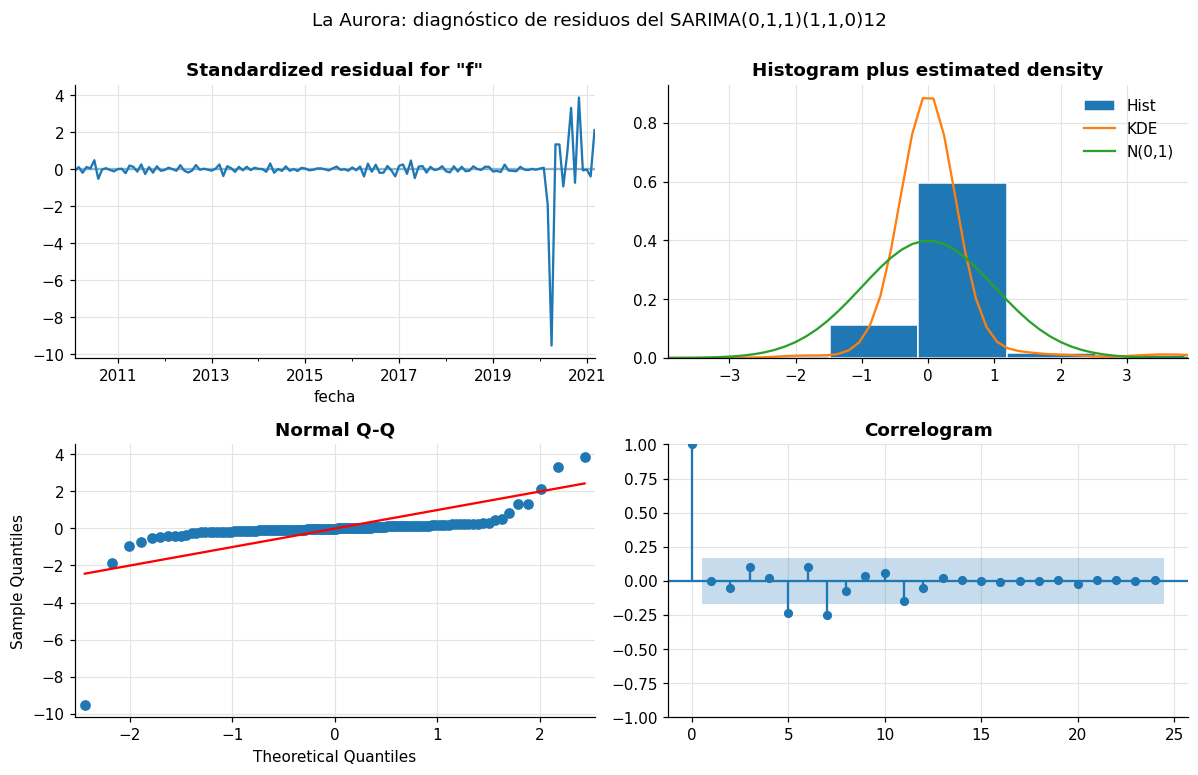

Los tres residuos más grandes (en log):
fecha
2020-04-01    4.60
2020-11-01    1.87
2020-09-01    1.60


In [5]:
mejor_aurora = ajustes_aurora["SARIMA(0, 1, 1)x(1, 1, 0)12"]
diagnostico_residuos(mejor_aurora, "La Aurora: diagnóstico de residuos del SARIMA(0,1,1)(1,1,0)12",
                     "modelado-aurora-residuos")
resid = mejor_aurora.resid[mejor_aurora.loglikelihood_burn:]
print("Los tres residuos más grandes (en log):")
print(resid.abs().nlargest(3).round(2).to_string())

El residuo dominante es **abril de 2020, con 4.6 desviaciones en escala log**: el mes del
cierre total del aeropuerto, donde la serie cayó a 484 visitantes. Le siguen otros meses de
2020. Ese bloque de residuos gigantes y correlacionados entre sí es lo que dispara el Ljung-Box
en el rezago 12 y engorda las colas del QQ-plot; fuera del tramo pandémico los residuos se ven
centrados, sin estructura y con el correlograma limpio. La autocorrelación residual es un
artefacto del cambio de régimen, no de una dinámica que el modelo deje sin capturar, así que la
aceptamos documentada en lugar de inflar el modelo con órdenes que no significan nada.

**Elegido para La Aurora: SARIMA(0,1,1)(1,1,0)₁₂ sobre el log.** Interpretación: tras quitar
tendencia (d = 1) y estacionalidad (D = 1), cada mes se corrige con el error del mes anterior
(término MA regular) y con lo que pasó el mismo mes del año pasado (término AR estacional).

### 2.3 Contraste con auto_arima

In [6]:
auto_aurora = pm.auto_arima(logs["frontera: La Aurora"], seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_aurora.order}x{auto_aurora.seasonal_order} | AIC {auto_aurora.aic():.1f}")
auto_aurora.summary().tables[1]

Propuesta de auto_arima: ARIMA(3, 0, 2)x(1, 0, 1, 12) | AIC 186.0


,coef,std err,z,P>|z|,[0.025,0.975]
intercept,0.1916,1.936,0.099,0.921,-3.604,3.987
ar.L1,-0.5841,0.118,-4.960,0.000,-0.815,-0.353
ar.L2,0.6412,0.100,6.405,0.000,0.445,0.837
ar.L3,0.4767,0.146,3.257,0.001,0.190,0.764
ma.L1,1.7403,0.093,18.774,0.000,1.559,1.922
ma.L2,0.9042,0.111,8.116,0.000,0.686,1.123
ar.S.L12,0.9633,0.370,2.606,0.009,0.239,1.688
ma.S.L12,-0.8634,0.855,-1.010,0.312,-2.538,0.811
sigma2,0.1746,0.027,6.490,0.000,0.122,0.227


auto_arima propone un **ARIMA(3,0,2)(1,0,1)₁₂ sin ninguna diferenciación**, con AIC 186.0.
¿Tiene sentido? No para nuestro uso, por tres razones. Primera: su AIC no es comparable con los
de la rejilla, porque con d = 0 la verosimilitud se calcula sobre otra serie; el número más
bajo no significa mejor modelo. Segunda: auto_arima decide d con la prueba KPSS, y en el
análisis preliminar vimos que el KPSS no rechaza la estacionariedad del nivel justamente porque
el colapso de 2020 anula once años de tendencia; el ADF, que sí mira la raíz unitaria, dice lo
contrario. Tercera: la tabla de coeficientes muestra dónde escondió la tendencia: el AR
estacional queda en 0.963 con un intervalo de confianza que incluye 1, es decir, imita la
diferencia estacional que se negó a hacer, y la parte MA(2) regular queda al borde de la no
invertibilidad (coeficientes 1.74 y 0.90). El modelo compensa con parámetros extremos lo que
una diferenciación resolvía. Mantenemos nuestra propuesta manual.

## 3. Valle Nuevo

### 3.1 Rejilla de modelos SARIMA

In [7]:
tabla_vnuevo, ajustes_vnuevo = ajustar_rejilla(logs["frontera: Valle Nuevo"])
tabla_vnuevo

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,323.2,331.9,0.171,0.848
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,323.7,332.4,0.133,0.807
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,324.6,333.2,0.076,0.698
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,325.7,337.3,0.133,0.807
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,325.7,337.3,0.133,0.807
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,328.6,334.3,0.115,0.762
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,330.6,339.2,0.115,0.762
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,333.2,345.1,0.064,0.662
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,335.2,350.1,0.066,0.669


El orden se repite: gana el **SARIMA(0,1,1)(1,1,0)₁₂** con AIC 323.2, empatado en la práctica
con el airline (323.7). La diferencia con La Aurora está en los residuos: aquí los Ljung-Box
pasan con holgura (0.171 en el rezago 12 y 0.848 en el 24 para el mejor modelo). Valle Nuevo
cayó en 2020 igual que La Aurora, pero su caída fue un descenso sostenido de varios meses en
lugar de un desplome de un solo mes, y eso el término MA lo absorbe mejor.

Las variantes con D = 0 vuelven a perder (AIC aparte, sus Ljung-Box son peores: 0.064 contra
0.171) y con ellas la ruta alternativa que el análisis preliminar dejó abierta para esta serie:
la diferencia estacional sí aporta.

### 3.2 Residuos del modelo elegido

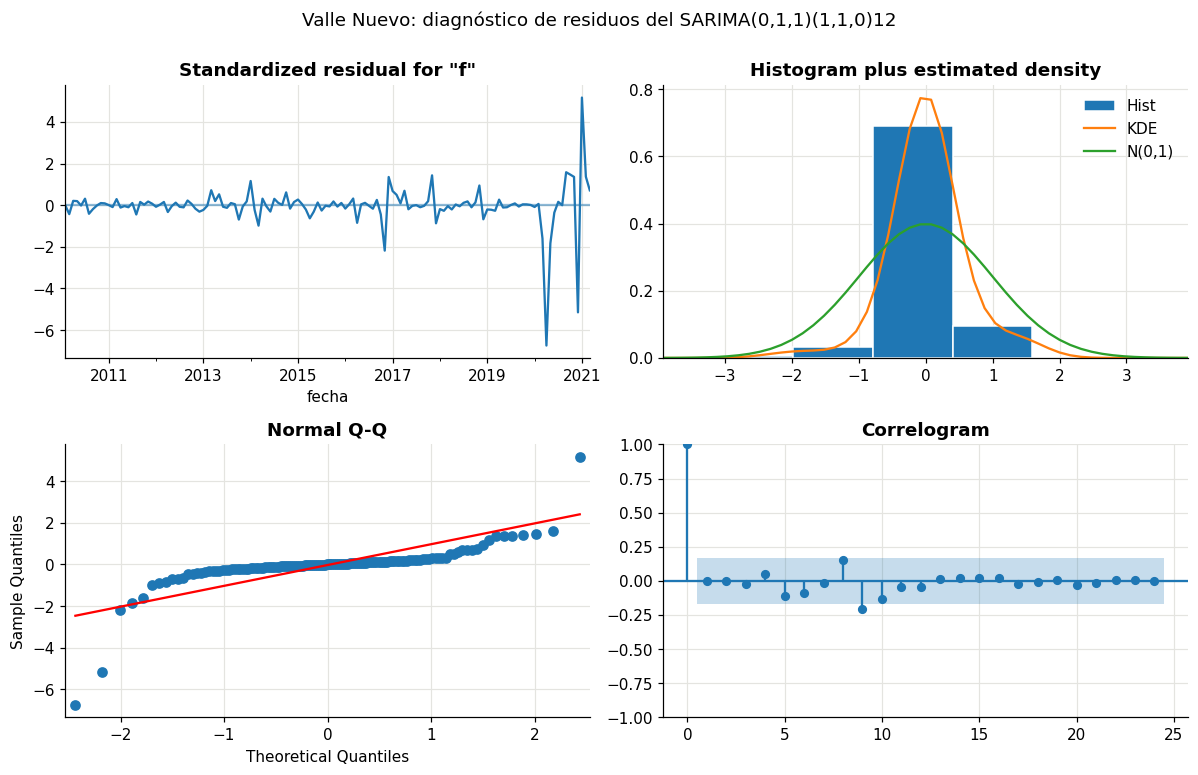

Los tres residuos más grandes (en log):
fecha
2020-04-01    5.28
2021-01-01    4.05
2020-12-01    4.03


In [8]:
mejor_vnuevo = ajustes_vnuevo["SARIMA(0, 1, 1)x(1, 1, 0)12"]
diagnostico_residuos(mejor_vnuevo, "Valle Nuevo: diagnóstico de residuos del SARIMA(0,1,1)(1,1,0)12",
                     "modelado-vnuevo-residuos")
resid = mejor_vnuevo.resid[mejor_vnuevo.loglikelihood_burn:]
print("Los tres residuos más grandes (en log):")
print(resid.abs().nlargest(3).round(2).to_string())

El correlograma de los residuos está limpio en todos los rezagos y el Ljung-Box lo confirma. El
QQ-plot vuelve a mostrar colas pesadas por el bloque pandémico (abril y diciembre 2020, enero
2021, con residuos de 4 a 5.3 en log: la serie pasó de 111 mil a 80 visitantes). Igual que en
La Aurora, es el cambio de régimen y no una falla de especificación.

**Elegido para Valle Nuevo: SARIMA(0,1,1)(1,1,0)₁₂ sobre el log**, el mismo del aeropuerto,
con la ventaja de que aquí los residuos pasan todas las pruebas de autocorrelación.

### 3.3 Contraste con auto_arima

In [9]:
auto_vnuevo = pm.auto_arima(logs["frontera: Valle Nuevo"], seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_vnuevo.order}x{auto_vnuevo.seasonal_order} | AIC {auto_vnuevo.aic():.1f}")

Propuesta de auto_arima: ARIMA(1, 0, 1)x(0, 0, 0, 12) | AIC 330.2


Aquí la propuesta automática es directamente insostenible: un **ARIMA(1,0,1) sin diferenciación
y sin ningún componente estacional**. Un modelo sin parte estacional para una serie cuyo índice
de diciembre es 130 y el de febrero 69 no puede reproducir el patrón anual que domina la serie;
pronosticaría un año plano. Es el mismo mecanismo de La Aurora (el KPSS engañado por el colapso
lleva a d = 0) agravado porque el tramo pandémico también diluye la señal estacional que el
procedimiento stepwise necesita para justificar P o Q. La propuesta se descarta y con ella
queda ilustrado el riesgo de usar auto_arima sin revisar el diagnóstico propio de la serie.

## 4. San Cristóbal

### 4.1 Rejilla de modelos SARIMA

In [10]:
tabla_scristobal, ajustes_scristobal = ajustar_rejilla(logs["frontera: San Cristóbal"])
tabla_scristobal

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,257.8,266.5,0.048,0.473
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,258.4,267.1,0.047,0.501
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,258.6,270.2,0.098,0.594
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,260.2,268.9,0.037,0.461
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,261.8,273.4,0.042,0.465
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,267.1,272.9,0.029,0.401
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,268.2,276.9,0.052,0.482
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,269.5,284.5,0.060,0.436
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,271.6,283.6,0.030,0.379


San Cristóbal es el único caso donde AIC y residuos apuntan a modelos distintos. El mínimo AIC
es el SARIMA(1,1,0)(0,1,1)₁₂ (257.8), pero su Ljung-Box en el rezago 12 queda al filo (0.048).
A 0.8 puntos de AIC, diferencia irrelevante, el **SARIMA(1,1,1)(0,1,1)₁₂** deja residuos
claramente más limpios (0.098 en el 12, 0.594 en el 24). Preferimos pagar un parámetro más a
cambio de residuos que pasan las pruebas: el AR(1) regular captura la inercia de la serie y el
MA(1) limpia lo que queda.

Nótese que la parte estacional elegida aquí es MA (Q = 1) y no AR como en las otras dos
fronteras, y que los modelos con D = 0 son los peores de la tabla, coherente con el análisis
preliminar: en esta serie la diferencia estacional era obligatoria (el ADF con solo d = 1 daba
p = 0.91).

### 4.2 Residuos del modelo elegido

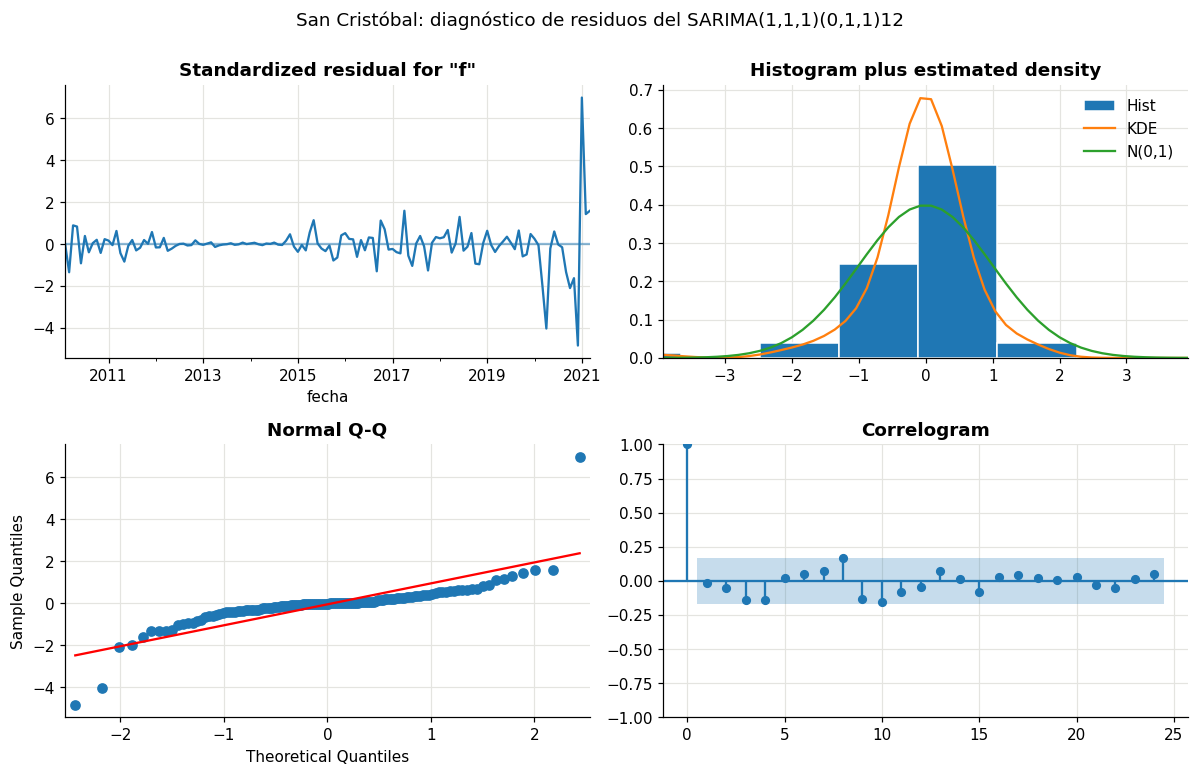

Los tres residuos más grandes (en log):
fecha
2021-01-01    4.27
2020-12-01    2.96
2020-04-01    2.46


In [11]:
mejor_scristobal = ajustes_scristobal["SARIMA(1, 1, 1)x(0, 1, 1)12"]
diagnostico_residuos(mejor_scristobal, "San Cristóbal: diagnóstico de residuos del SARIMA(1,1,1)(0,1,1)12",
                     "modelado-scristobal-residuos")
resid = mejor_scristobal.resid[mejor_scristobal.loglikelihood_burn:]
print("Los tres residuos más grandes (en log):")
print(resid.abs().nlargest(3).round(2).to_string())

Mismo patrón que las demás: correlograma residual limpio, colas pesadas por la pandemia
(diciembre 2020 y enero 2021, la serie tocó 14 visitantes). Fuera de ese bloque el modelo sigue
bien una serie que es la más ruidosa del grupo (el residuo de la descomposición prepandemia era
del 21%).

**Elegido para San Cristóbal: SARIMA(1,1,1)(0,1,1)₁₂ sobre el log.**

### 4.3 Contraste con auto_arima

In [12]:
auto_scristobal = pm.auto_arima(logs["frontera: San Cristóbal"], seasonal=True, m=12,
                                stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_scristobal.order}x{auto_scristobal.seasonal_order} | AIC {auto_scristobal.aic():.1f}")

Propuesta de auto_arima: ARIMA(3, 0, 4)x(2, 0, 0, 12) | AIC 264.3


Tercera vez el mismo defecto: **ARIMA(3,0,4)(2,0,0)₁₂ con d = 0 y D = 0**, ahora además con
nueve parámetros ARMA, el modelo más pesado que ha propuesto para la serie con menos señal por
mes. Para una serie donde la evidencia estadística exige las dos diferenciaciones, una
propuesta sin ninguna no tiene sentido; el exceso de parámetros es la compensación. Se
descarta.

## 5. Resumen del modelado ARIMA de fronteras

| Serie | Modelo elegido | AIC | BIC | Ljung-Box p (12 / 24) |
|---|---|---|---|---|
| La Aurora | SARIMA(0,1,1)(1,1,0)₁₂ en log | 194.8 | 203.5 | 0.013 / 0.373 |
| Valle Nuevo | SARIMA(0,1,1)(1,1,0)₁₂ en log | 323.2 | 331.9 | 0.171 / 0.848 |
| San Cristóbal | SARIMA(1,1,1)(0,1,1)₁₂ en log | 258.6 | 270.2 | 0.098 / 0.594 |

Tres lecturas cierran esta parte.

**La estructura es casi la misma en las tres fronteras.** Diferenciación regular y estacional,
un término regular de corrección y un término estacional. Es la estructura airline con
variantes menores, y confirma que los candidatos leídos de los correlogramas en el análisis
preliminar iban bien encaminados: en ninguna serie la rejilla encontró algo sustancialmente
mejor que el punto de partida.

**Los residuos aprueban con una excepción explicada.** Valle Nuevo y San Cristóbal pasan
Ljung-Box en todos los rezagos. La Aurora no pasa en el 12 con ningún candidato, y el
diagnóstico muestra por qué: el residuo de 4.6 desviaciones de abril 2020, el mes del cierre
del aeropuerto. Es un límite de los datos, no del modelo, y quedará igualmente expuesto en los
algoritmos alternativos.

**auto_arima falló en las tres series y siempre por lo mismo.** Su prueba de raíz unitaria por
defecto (KPSS) lee el colapso pandémico como ausencia de tendencia y concluye d = 0; después
compensa con partes AR al borde de la raíz unitaria (La Aurora), sin estacionalidad (Valle
Nuevo) o sobreparametrizadas (San Cristóbal). Con series que traen un cambio de régimen, la
selección automática necesita supervisión: nuestro diagnóstico manual con ADF más correlogramas
produjo modelos más simples y con mejores residuos.

## 6. Modelos alternativos y pronóstico sobre la prueba

Ajustamos ahora los algoritmos del inciso 4h para cada frontera: **Prophet**, **Holt-Winters**
(con y sin amortiguamiento de tendencia), **suavizamiento exponencial simple** y **seasonal
naive**. Todos se entrenan con los mismos 147 meses y pronostican los 63 meses de la prueba
(abril 2021 a junio 2026) de una sola vez, sin ver ningún dato de ese período. Todos trabajan
en logaritmo, igual que los SARIMA, salvo el seasonal naive que repite tal cual los últimos
doce meses observados. Las métricas MAE y RMSE se calculan en la escala original de visitantes.

Este es el escenario más difícil posible: el entrenamiento termina en el piso pandémico y el
horizonte es de cinco años. Ningún algoritmo tiene información para anticipar la reapertura,
así que lo que se compara aquí es qué supuesto de continuación falla menos.

In [13]:
import logging
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)  # prophet imprime el log de stan por defecto

from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

test = pd.read_csv(RAIZ / "data" / "processed" / "series_test.csv", parse_dates=["fecha"]).set_index("fecha").asfreq("MS")
H = len(test)


def pronosticos_alternativos(nombre, resultado_sarima):
    """Pronóstico estático de 63 meses con cada algoritmo, en escala original."""
    y, ylog = train[nombre], logs[nombre]
    idx = test.index
    preds = {"SARIMA elegido": np.exp(resultado_sarima.forecast(H))}
    hw = ExponentialSmoothing(ylog, trend="add", seasonal="add", seasonal_periods=12).fit()
    preds["Holt-Winters"] = np.exp(hw.forecast(H))
    hwd = ExponentialSmoothing(ylog, trend="add", damped_trend=True, seasonal="add",
                               seasonal_periods=12).fit()
    preds["Holt-Winters amortiguado"] = np.exp(hwd.forecast(H))
    preds["Suav. exponencial simple"] = np.exp(SimpleExpSmoothing(ylog).fit().forecast(H))
    m = Prophet(seasonality_mode="additive", yearly_seasonality=True,
                weekly_seasonality=False, daily_seasonality=False)
    m.fit(pd.DataFrame({"ds": ylog.index, "y": ylog.values}))
    futuro = m.make_future_dataframe(periods=H, freq="MS")
    preds["Prophet"] = pd.Series(np.exp(m.predict(futuro)["yhat"].values[-H:]), index=idx)
    preds["Seasonal naive"] = pd.Series(np.tile(y.iloc[-12:].values, 6)[:H], index=idx)
    return {k: pd.Series(np.asarray(v), index=idx) for k, v in preds.items()}


def tabla_errores(nombre, preds):
    yt = test[nombre]
    filas = {}
    for k, p in preds.items():
        e = yt.values - p.values
        filas[k] = {"MAE": round(np.mean(np.abs(e))), "RMSE": round(np.sqrt(np.mean(e ** 2))),
                    "pred. media": round(p.mean()), "real medio": round(yt.mean())}
    return pd.DataFrame(filas).T.sort_values("MAE")


COLORES_MODELO = {"SARIMA elegido": NARANJA, "Holt-Winters amortiguado": AQUA,
                  "Suav. exponencial simple": AMARILLO, "Prophet": MAGENTA, "Seasonal naive": GRIS}


def graficar_pronosticos(nombre, preds, nombre_figura):
    yt = test[nombre]
    fig, eje = plt.subplots(figsize=(12, 4.6))
    eje.plot(train[nombre].iloc[-36:], color=AZUL, lw=1.4, label="entrenamiento (últimos 3 años)")
    eje.plot(yt, color="#222222", lw=1.8, label="real (prueba)")
    for k, color in COLORES_MODELO.items():
        eje.plot(preds[k], color=color, lw=1.1, ls="--", label=k)
    eje.set_title(f"{nombre}: pronóstico estático de 63 meses contra la realidad")
    eje.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    eje.legend(loc="upper left", fontsize=8)
    guardar(nombre_figura)
    plt.show()

Importing plotly failed. Interactive plots will not work.


### 6.1 La Aurora

08:58:55 - cmdstanpy - INFO - Chain [1] start processing


08:58:55 - cmdstanpy - INFO - Chain [1] done processing


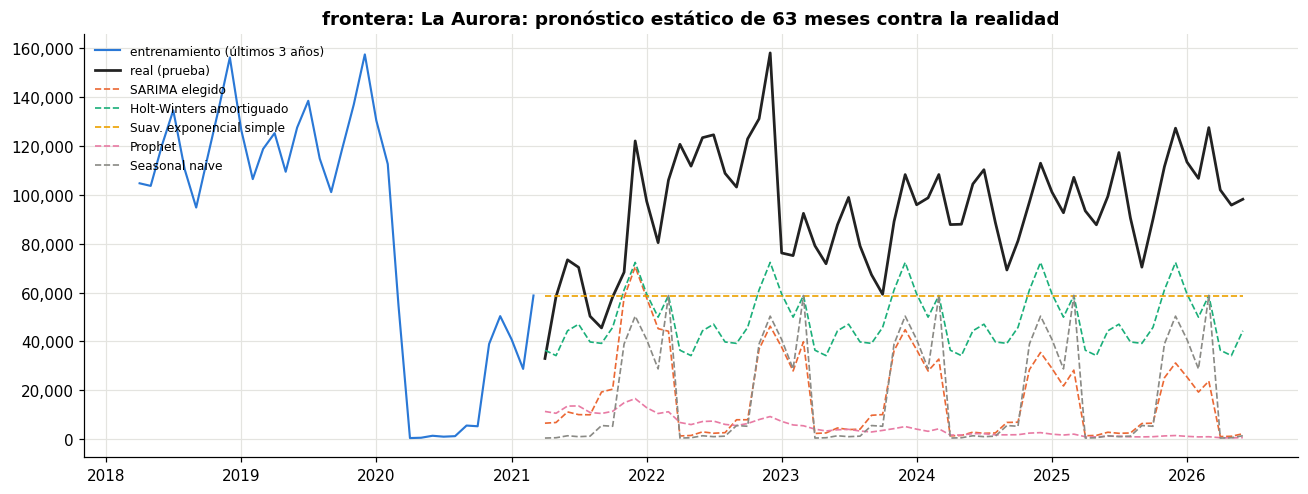

,MAE,RMSE,pred. media,real medio
Suav. exponencial simple,36822,42053,58806,94087
Holt-Winters amortiguado,45661,49754,48534,94087
Holt-Winters,48963,53028,45231,94087
Seasonal naive,75518,79321,18569,94087
SARIMA elegido,76426,80619,17661,94087
Prophet,89068,92284,5020,94087


In [14]:
preds_aurora = pronosticos_alternativos("frontera: La Aurora", mejor_aurora)
graficar_pronosticos("frontera: La Aurora", preds_aurora, "modelado-aurora-pronosticos")
tabla_errores("frontera: La Aurora", preds_aurora)

Todos los modelos subestiman, y mucho: el promedio real de la prueba es 94 mil visitantes al
mes y la mejor predicción media es 59 mil. El ranking lo explica el anclaje. Gana el
**suavizamiento exponencial simple** (MAE 36,822) porque su pronóstico es una línea plana en el
último nivel observado, y marzo 2021 ya recuperaba el 48% del nivel prepandemia; no sabe nada
de estacionalidad ni tendencia, pero parte del punto menos malo. Le siguen los Holt-Winters
(45 a 49 mil), que arrastran además una tendencia aprendida a la baja. El SARIMA (76,426) y el
seasonal naive (75,518) quedan casi empatados porque ambos proyectan el patrón del último año
observado, que es el año del cierre. Prophet es el peor (89,068): su tendencia por tramos
termina cayendo y extrapola la caída.

### 6.2 Valle Nuevo

08:58:56 - cmdstanpy - INFO - Chain [1] start processing


08:58:56 - cmdstanpy - INFO - Chain [1] done processing


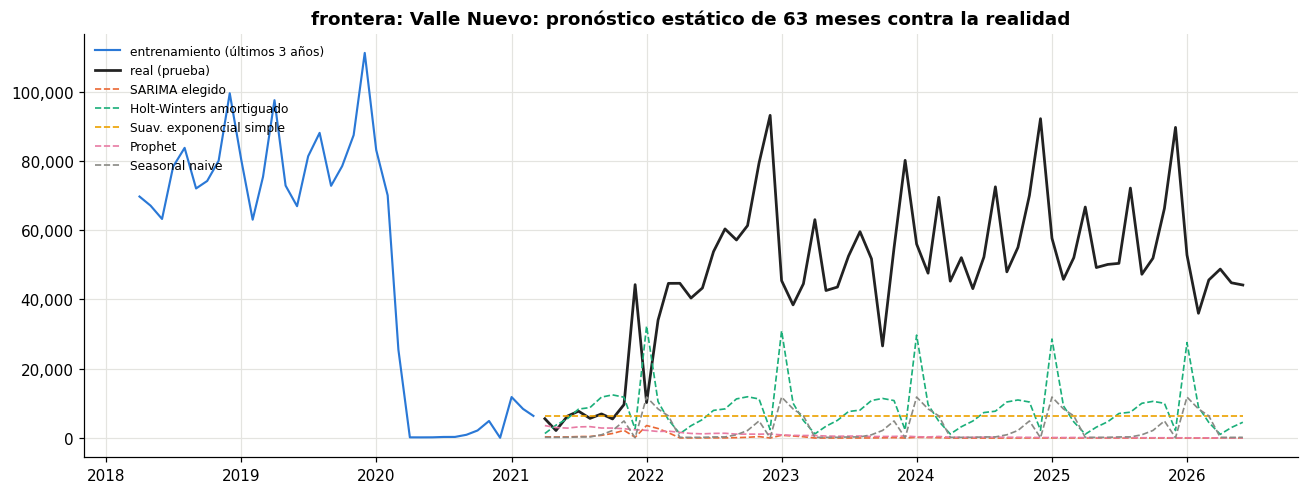

,MAE,RMSE,pred. media,real medio
Holt-Winters amortiguado,40324,45443,8510,47524
Suav. exponencial simple,41311,46237,6432,47524
Holt-Winters,41709,46721,6997,47524
Seasonal naive,44707,49661,2867,47524
Prophet,46656,51523,895,47524
SARIMA elegido,47238,51906,286,47524


In [15]:
preds_vnuevo = pronosticos_alternativos("frontera: Valle Nuevo", mejor_vnuevo)
graficar_pronosticos("frontera: Valle Nuevo", preds_vnuevo, "modelado-vnuevo-pronosticos")
tabla_errores("frontera: Valle Nuevo", preds_vnuevo)

Aquí el fracaso es total y parejo: el MAE de todos los modelos (40 a 47 mil) es casi igual al
nivel medio real de la prueba (47,524), es decir, **todos predicen prácticamente cero**. La
razón está en el punto de corte: Valle Nuevo cerró el entrenamiento en el 8% de su nivel
prepandemia, con la frontera terrestre aún cerrada. El "mejor" es Holt-Winters amortiguado
(40,324) por décimas de anclaje, una victoria sin contenido. Ningún modelo entrenado hasta
marzo 2021 sirve para pronosticar esta serie a cinco años; la comparación útil está en la
sección 7.

### 6.3 San Cristóbal

08:58:56 - cmdstanpy - INFO - Chain [1] start processing


08:58:56 - cmdstanpy - INFO - Chain [1] done processing


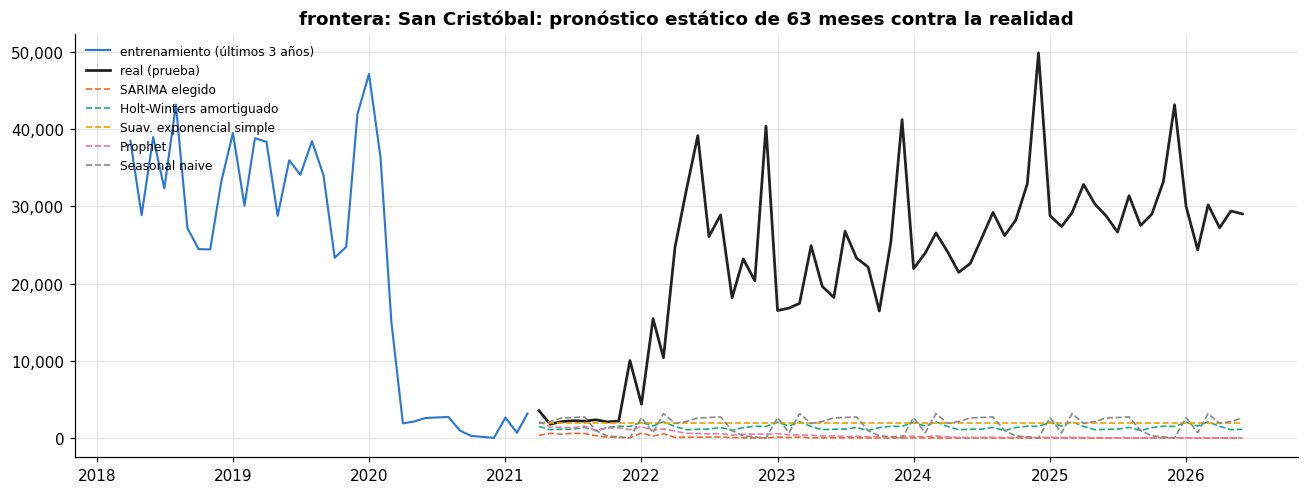

,MAE,RMSE,pred. media,real medio
Suav. exponencial simple,21103,23740,1940,23039
Seasonal naive,21408,24053,1687,23039
Holt-Winters amortiguado,21605,24188,1434,23039
Holt-Winters,21992,24597,1047,23039
Prophet,22612,25268,428,23039
SARIMA elegido,22945,25449,94,23039


In [16]:
preds_scristobal = pronosticos_alternativos("frontera: San Cristóbal", mejor_scristobal)
graficar_pronosticos("frontera: San Cristóbal", preds_scristobal, "modelado-scristobal-pronosticos")
tabla_errores("frontera: San Cristóbal", preds_scristobal)

El mismo cuadro que Valle Nuevo: MAE de 21 a 23 mil contra un nivel real de 23 mil, todos los
modelos pronostican cerca de cero y las diferencias entre algoritmos (suavizamiento simple
21,103 contra SARIMA 22,945) son ruido de anclaje, no capacidad de pronóstico. Las dos
fronteras terrestres confirman lo que advertimos desde el análisis preliminar: con el corte
70/30 el pronóstico estático multianual es un ejercicio imposible para las series que quedaron
en el piso al momento del corte.

## 7. Predicción a un paso: la comparación que sí discrimina

El pronóstico estático responde una pregunta que nadie haría en la práctica: qué pasa si
congelamos el modelo en marzo 2021 y no volvemos a mirar los datos en cinco años. El uso real
es pronosticar el mes siguiente incorporando cada dato nuevo. Evaluamos eso con una predicción
a un paso tipo walk-forward: los parámetros del SARIMA quedan fijos (los del entrenamiento,
sin reestimar) y el filtro avanza mes a mes sobre la prueba prediciendo siempre el mes
siguiente. Como referencia usamos el seasonal naive a un paso, que predice cada mes con el
valor real del mismo mes del año anterior.

In [17]:
def sarima_un_paso(nombre, resultado):
    serie_completa = np.log(pd.concat([train[nombre], test[nombre]]))
    filtrado = resultado.apply(serie_completa)  # mismos parámetros, filtro sobre toda la serie
    pred = np.exp(filtrado.get_prediction(start=test.index[0], dynamic=False).predicted_mean)
    return pred


filas = []
for nombre, resultado in [("frontera: La Aurora", mejor_aurora),
                          ("frontera: Valle Nuevo", mejor_vnuevo),
                          ("frontera: San Cristóbal", mejor_scristobal)]:
    yt = test[nombre]
    p_sarima = sarima_un_paso(nombre, resultado)
    p_naive = pd.concat([train[nombre], yt]).shift(12).loc[test.index]
    for etiq, p in [("SARIMA (1 paso)", p_sarima), ("Seasonal naive (1 paso)", p_naive)]:
        e = yt.values - p.values
        filas.append({"serie": nombre.replace("frontera: ", ""), "modelo": etiq,
                      "MAE": round(np.mean(np.abs(e))), "RMSE": round(np.sqrt(np.mean(e ** 2)))})
pd.DataFrame(filas).set_index(["serie", "modelo"])

MAE   RMSE
serie         modelo                               
La Aurora     SARIMA (1 paso)          24747  45742
              Seasonal naive (1 paso)  29404  37367
Valle Nuevo   SARIMA (1 paso)          21224  43854
              Seasonal naive (1 paso)  15692  23311
San Cristóbal SARIMA (1 paso)           7137  16062
              Seasonal naive (1 paso)   7490  11349

El cambio es drástico y ahora sí hay señal. En **La Aurora** el MAE del SARIMA baja de 76,426
(estático) a **24,747**, un 26% del nivel medio, y le gana al naive a un paso (29,404): la
estructura estacional y el término de corrección aportan sobre el simple año anterior. En **San
Cristóbal** el SARIMA (7,137) también supera al naive (7,490) por poco. En **Valle Nuevo** gana
el naive (15,692 contra 21,224): durante la reapertura escalonada de la frontera terrestre, el
mismo mes del año pasado resultó mejor predictor que la dinámica aprendida en un entrenamiento
que terminó en el piso.

Las dos métricas no cuentan la misma historia y vale decirlo: en MAE el SARIMA gana en La
Aurora y San Cristóbal, pero en RMSE el naive gana en las tres series. El RMSE castiga los
errores grandes, y el SARIMA los concentra en los primeros meses de la reapertura, cuando su
filtro todavía arrastra el régimen del cierre; el naive, que copia el año anterior real, no
produce esos fallos extremos. En error típico mes a mes (MAE) el SARIMA es mejor; en robustez
ante meses atípicos (RMSE) lo es el naive.

La lectura de fondo: los modelos ARIMA elegidos no eran malos, el horizonte estático era
imposible. En cuanto se les permite ver los datos recientes, recuperan capacidad de pronóstico
razonable en una serie que atravesó el evento más disruptivo de su historia.

## 8. Selección del mejor modelo por serie

Con las dos evaluaciones sobre la mesa, la selección del inciso 4k queda así:

| Serie | Estático 63 meses (menor MAE) | A un paso (menor MAE) | Modelo seleccionado |
|---|---|---|---|
| La Aurora | Suav. exponencial simple (36,822) | SARIMA (24,747) | **SARIMA(0,1,1)(1,1,0)₁₂ en log** |
| Valle Nuevo | Holt-Winters amortiguado (40,324) | Seasonal naive (15,692) | **Seasonal naive a un paso** |
| San Cristóbal | Suav. exponencial simple (21,103) | SARIMA (7,137) | **SARIMA(1,1,1)(0,1,1)₁₂ en log** |

El criterio: el ranking estático premia el anclaje al último nivel, no la comprensión de la
serie, así que pesa menos; el ranking a un paso mide el uso operativo real. Para La Aurora y
San Cristóbal seleccionamos sus SARIMA, que ganan en MAE a un paso y además traen estructura
interpretable y residuos validados; anotamos que en RMSE el naive les gana por los meses
iniciales de la reapertura, donde el SARIMA falla en grande. Para Valle Nuevo la evidencia
manda seleccionar el seasonal naive, que gana en ambas métricas, mientras dure la fase de
normalización pos-reapertura: cuando la serie acumule dos o tres años de régimen estable, el
SARIMA debería reevaluarse.

Dos advertencias cierran. Primera: ningún modelo entrenado con el corte del enunciado sirve
para pronóstico multianual; cualquier uso institucional de estos modelos requiere reentrenarlos
con datos posteriores a la reapertura. Segunda: las métricas de Prophet aquí no condenan al
algoritmo, condenan la extrapolación de una tendencia quebrada; con regresores de intervención
o puntos de quiebre manuales su desempeño cambiaría.

## 9. Análisis comparativo entre las tres fronteras

Cierra la categoría de fronteras el inciso 5a: cuál serie presenta mayor estacionalidad, mayor
tendencia de crecimiento, mayor volatilidad y cuál fue la más afectada por la pandemia. Para
esta parte usamos la serie completa (entrenamiento más prueba, enero 2009 a junio 2026): aquí
no se pronostica nada, se describe, y truncar en 2021 escondería justamente el tramo que
responde la pregunta de la pandemia. Los indicadores de estacionalidad, tendencia y volatilidad
se calculan sobre el tramo prepandemia (2009 a 2019) para que el colapso no los contamine; los
de pandemia, sobre 2020 en adelante.

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

completa = pd.concat([train, test])
NOMBRES = ["frontera: La Aurora", "frontera: Valle Nuevo", "frontera: San Cristóbal"]

filas = {}
for nombre in NOMBRES:
    s = completa[nombre]
    pre = s[:"2019-12"]
    indices = seasonal_decompose(pre, model="multiplicative", period=12).seasonal.groupby(lambda d: d.month).mean() * 100
    desc_log = seasonal_decompose(np.log(pre), model="additive", period=12)
    fuerza_estacional = max(0, 1 - desc_log.resid.var() / (desc_log.resid + desc_log.seasonal).var())
    promedio_2019 = s["2019"].mean()
    recupera = s["2020-04":][s["2020-04":] >= promedio_2019]
    filas[nombre.replace("frontera: ", "")] = {
        "banda estacional (min-max)": f"{indices.min():.0f} a {indices.max():.0f}",
        "amplitud estacional": round(indices.max() - indices.min()),
        "fuerza estacional Fs": round(fuerza_estacional, 2),
        "CAGR 2009-2019": f"{(pre['2019'].sum() / pre['2009'].sum()) ** (1 / 10) - 1:.1%}",
        "CV prepandemia": round(pre.std() / pre.mean(), 2),
        "std dif. log prepandemia": round(np.log(pre).diff().std(), 2),
        "caída abril 2020": f"{s['2020-04-01'] / promedio_2019 - 1:.1%}",
        "mínimo pandémico": f"{s['2020':'2021'].min():,.0f}",
        "meses debajo del 50% de 2019": int((s["2020-03":] < 0.5 * promedio_2019).sum()),
        "primer mes que iguala 2019": f"{recupera.index[0]:%Y-%m}",
        "déficit mar 2020-dic 2021": f"{1 - s['2020-03':'2021-12'].sum() / (promedio_2019 * 22):.0%}",
        "2025 como % de 2019": f"{s['2025'].sum() / s['2019'].sum():.0%}",
    }
pd.DataFrame(filas)

,La Aurora,Valle Nuevo,San Cristóbal
banda estacional (min-max),80 a 125,69 a 130,62 a 143
amplitud estacional,45,61,81
fuerza estacional Fs,0.9,0.36,0.6
CAGR 2009-2019,4.7%,9.7%,12.9%
CV prepandemia,0.22,0.4,0.52
std dif. log prepandemia,0.17,0.37,0.35
caída abril 2020,-99.6%,-99.8%,-94.4%
mínimo pandémico,484,80,14
meses debajo del 50% de 2019,19,27,28
primer mes que iguala 2019,2022-07,2022-12,2022-06


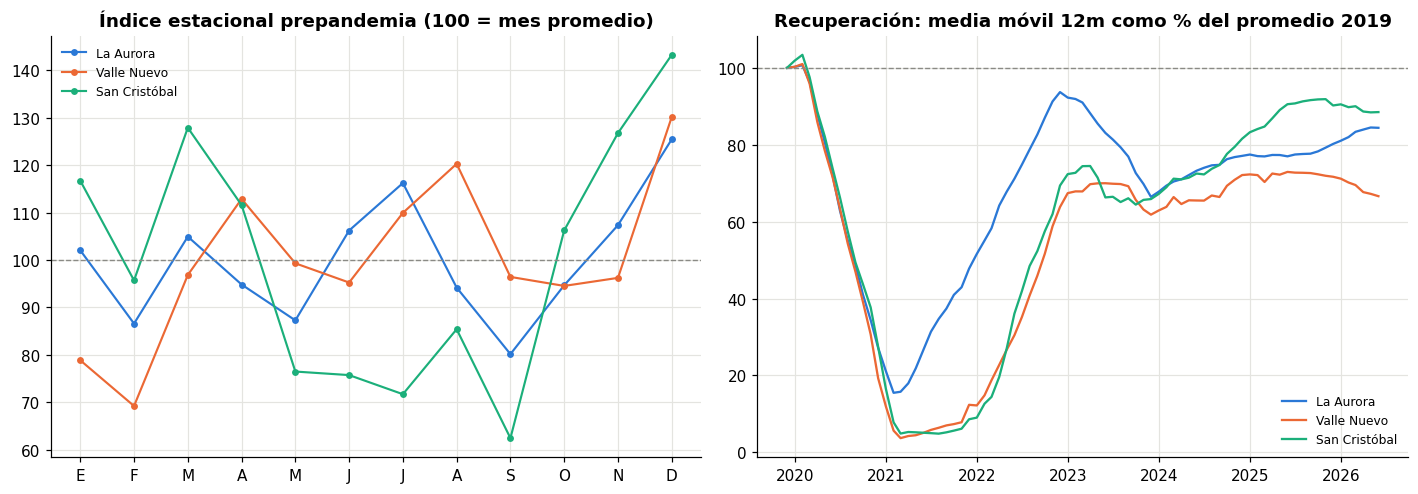

In [19]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.6))
colores_frontera = {"frontera: La Aurora": AZUL, "frontera: Valle Nuevo": NARANJA,
                    "frontera: San Cristóbal": AQUA}

for nombre, color in colores_frontera.items():
    pre = completa[nombre][:"2019-12"]
    indices = seasonal_decompose(pre, model="multiplicative", period=12).seasonal.groupby(lambda d: d.month).mean() * 100
    ejes[0].plot(indices.index, indices.values, color=color, marker="o", ms=3.5, lw=1.4,
                 label=nombre.replace("frontera: ", ""))
ejes[0].axhline(100, color=GRIS, lw=0.9, ls="--")
ejes[0].set_title("Índice estacional prepandemia (100 = mes promedio)")
ejes[0].set_xticks(range(1, 13))
ejes[0].set_xticklabels(["E", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ejes[0].legend(fontsize=8)

for nombre, color in colores_frontera.items():
    s = completa[nombre]["2019":]
    base = s[:"2019-12"].mean()
    ejes[1].plot(s.index, s.rolling(12).mean() / base * 100, color=color, lw=1.5,
                 label=nombre.replace("frontera: ", ""))
ejes[1].axhline(100, color=GRIS, lw=0.9, ls="--")
ejes[1].set_title("Recuperación: media móvil 12m como % del promedio 2019")
ejes[1].legend(fontsize=8, loc="lower right")

guardar("modelado-comparativo-fronteras")
plt.show()

Con la tabla y las dos figuras, las respuestas del inciso 5a quedan así.

**¿Cuál presenta mayor estacionalidad? San Cristóbal**, con la banda estacional más ancha: sus
meses van del 62% al 143% del mes promedio, una amplitud de 81 puntos contra 61 de Valle Nuevo
y 45 de La Aurora. El matiz está en la regularidad: la fuerza estacional (la proporción de la
varianza no tendencial que explica el componente estacional) es máxima en La Aurora (0.90
contra 0.60 de San Cristóbal), porque el patrón aéreo se repite con precisión casi de reloj
mientras el de San Cristóbal, aunque más amplio, es más ruidoso. San Cristóbal oscila más; La
Aurora oscila más puntualmente.

**¿Cuál presenta mayor tendencia de crecimiento? San Cristóbal**, sin discusión: creció al
12.9% anual compuesto entre 2009 y 2019 (de 121 mil a 408 mil visitantes al año, se multiplicó
por 3.4), contra 9.7% de Valle Nuevo y 4.7% de La Aurora. Las fronteras terrestres con El
Salvador fueron el motor de crecimiento del período; el aeropuerto creció a la mitad del ritmo.

**¿Cuál presenta mayor volatilidad? San Cristóbal**, con el coeficiente de variación
prepandemia más alto (0.52 contra 0.40 de Valle Nuevo y 0.22 de La Aurora). En la variación mes
a mes (desviación de la diferencia logarítmica) Valle Nuevo empata en la práctica (0.37 contra
0.35), así que la volatilidad es un rasgo terrestre en general, pero el conjunto de indicadores
corona a San Cristóbal, la serie que además tenía el residuo de descomposición más alto (21%).

**¿Cuál fue la más afectada por la pandemia? Valle Nuevo.** La Aurora cayó más en el primer mes
(-99.6% en abril 2020 contra -94.4% de San Cristóbal) porque el cierre aéreo fue total e
inmediato, pero el daño acumulado fue mayor en las terrestres y sobre todo en Valle Nuevo:
déficit del 91% entre marzo 2020 y diciembre 2021 (contra 68% de La Aurora), mínimo pandémico
en diciembre 2020 (80 visitantes, cuando La Aurora ya se recuperaba), fue la última en volver a
su promedio 2019 (diciembre 2022, contra junio 2022 de San Cristóbal y julio 2022 de La Aurora)
y en 2025 sigue siendo la más rezagada, con el 72% de su nivel 2019 contra 90% de San Cristóbal
y 80% de La Aurora. Profundidad, duración y secuela apuntan a la misma serie.

El panel derecho de la figura deja una lectura adicional para el análisis general: la
recuperación tuvo dos velocidades, primero el aeropuerto (reapertura aérea, septiembre 2020) y
casi un año después las fronteras terrestres, y a 2026 ninguna de las tres ha vuelto en media
móvil anual a su nivel 2019 sostenido. La comparación entre regiones y las conclusiones para el
INGUAT quedan para la fase 2 del trabajo.